In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [169]:
dataset=pd.read_csv("pricing.csv")

In [170]:
print(dataset.columns)

Index(['Unnamed: 0', 'name', 'year', 'selling_price', 'km_driven', 'fuel',
       'seller_type', 'transmission', 'owner', 'seats', 'max_power (in bph)',
       'Mileage Unit', 'Mileage', 'Engine (CC)'],
      dtype='object')


In [171]:
dataset = dataset.drop(columns=["Unnamed: 0"]) 
# dataset = dataset.drop("Unnamed: 0", axis=1) yai bhi sahi hai
print(dataset.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'seats', 'max_power (in bph)', 'Mileage Unit',
       'Mileage', 'Engine (CC)'],
      dtype='object')


In [172]:
x=dataset.drop("selling_price",axis=1)
y=dataset["selling_price"]
print(x)
print(y)

         name  year  km_driven    fuel seller_type transmission         owner  \
0      Maruti  2014     145500  Diesel  Individual       Manual   First Owner   
1     Hyundai  2010     127000  Diesel  Individual       Manual   First Owner   
2     Hyundai  2017      45000  Petrol  Individual       Manual   First Owner   
3      Toyota  2011      90000  Diesel  Individual       Manual   First Owner   
4        Ford  2013     169000  Diesel  Individual       Manual   First Owner   
...       ...   ...        ...     ...         ...          ...           ...   
2090   Maruti  2017      12000  Petrol  Individual       Manual   First Owner   
2091   Toyota  2014      50000  Diesel  Individual       Manual   First Owner   
2092   Maruti  2011      73000  Petrol  Individual       Manual   First Owner   
2093   Maruti  2017      80000  Petrol  Individual       Manual   First Owner   
2094  Hyundai  2014      80000  Diesel  Individual       Manual  Second Owner   

      seats  max_power (in 

In [174]:
print(type(x))
pd.DataFrame(x).nunique()#unique data type bata rha sab col ka

<class 'pandas.core.frame.DataFrame'>


name                   10
year                   20
km_driven             372
fuel                    4
seller_type             3
transmission            2
owner                   5
seats                   4
max_power (in bph)     77
Mileage Unit            2
Mileage                86
Engine (CC)            27
dtype: int64

In [175]:
print(x.shape)
print(x.columns)

(2095, 12)
Index(['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission',
       'owner', 'seats', 'max_power (in bph)', 'Mileage Unit', 'Mileage',
       'Engine (CC)'],
      dtype='object')


In [176]:
print(x.iloc[:,0].values)

['Maruti' 'Hyundai' 'Hyundai' ... 'Maruti' 'Maruti' 'Hyundai']


In [177]:
print(dataset.iloc[:, 4].values)
print(dataset.dtypes)

['Diesel' 'Diesel' 'Petrol' ... 'Petrol' 'Petrol' 'Diesel']
name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
seats                   int64
max_power (in bph)    float64
Mileage Unit           object
Mileage               float64
Engine (CC)             int64
dtype: object


In [178]:
print(type(x))
print(x.dtypes)

<class 'pandas.core.frame.DataFrame'>
name                   object
year                    int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
seats                   int64
max_power (in bph)    float64
Mileage Unit           object
Mileage               float64
Engine (CC)             int64
dtype: object


In [179]:
print(type(x))

<class 'pandas.core.frame.DataFrame'>


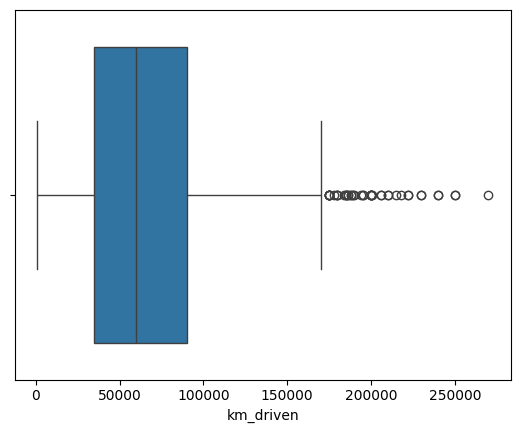

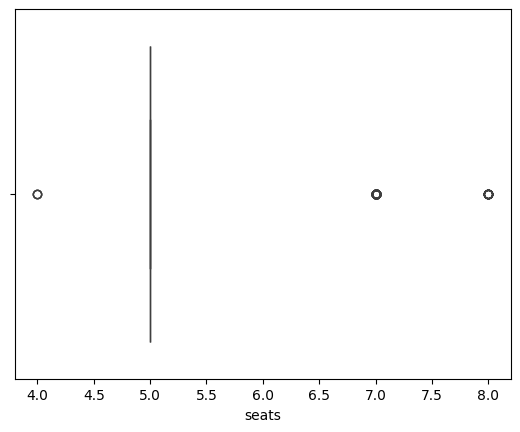

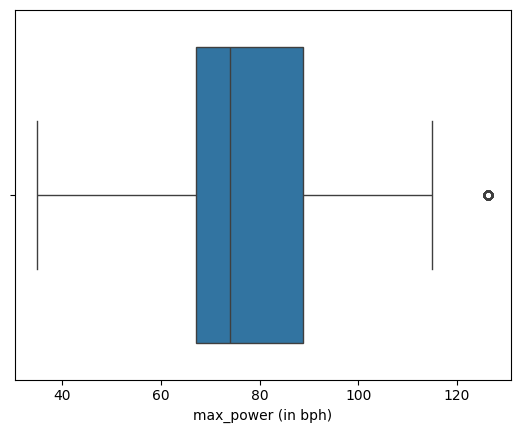

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt
# outlier detect
sns.boxplot(x=dataset["km_driven"])
plt.show()
sns.boxplot(x=dataset["seats"])
plt.show()
sns.boxplot(x=dataset["max_power (in bph)"])#in sab mai outlier  hai
plt.show()


In [181]:
from sklearn.base import BaseEstimator, TransformerMixin
class OutlierHandler(BaseEstimator, TransformerMixin):
    def fit(self, x, y=None):
        self.Q1 = np.percentile(x, 25, axis=0)
        self.Q3 = np.percentile(x, 75, axis=0)
        self.IQR = self.Q3 - self.Q1
        return self
    
    def transform(self, x):
        lower = self.Q1 - 1.5 * self.IQR
        upper = self.Q3 + 1.5 * self.IQR
        
        x= np.clip(x, lower, upper)
        return x

In [182]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

num_cols = x.select_dtypes(include=np.number).columns
cat_cols = x.select_dtypes(exclude=np.number).columns
ct = ColumnTransformer([
    ('num',Pipeline([
        ('impute',SimpleImputer(strategy='mean')),
        ('outliers', OutlierHandler()),
        ('scaling', StandardScaler())
    ]), num_cols),
    
    ('cat', Pipeline([
        ('impute',SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder())
    ]), cat_cols)
])

x = ct.fit_transform(x)

In [183]:
print(dataset['owner'].unique())
print(dataset['Mileage Unit'].nunique())
print(dataset['seller_type'].nunique())

['First Owner' 'Second Owner' 'Third Owner' 'Fourth & Above Owner'
 'Test Drive Car']
2
3


In [162]:
print(type(x))

<class 'numpy.ndarray'>


In [185]:
print(x.shape)
pd.DataFrame(x).nunique()#temporarily DataFrame me convert ho raha hai Fir .nunique() apply ho raha hai

(2095, 32)


0      17
1     350
2       1
3      74
4      86
5      27
6       2
7       2
8       2
9       2
10      2
11      2
12      2
13      2
14      2
15      2
16      2
17      2
18      2
19      2
20      2
21      2
22      2
23      2
24      2
25      2
26      2
27      2
28      2
29      2
30      2
31      2
dtype: int64

In [186]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0)
x = vt.fit_transform(x)

In [187]:
from sklearn.feature_selection import SelectKBest, f_classif
selector=SelectKBest(score_func=f_classif,k=7)
x_new=selector.fit_transform(x,y)

C:\Users\mehak\AppData\Roaming\Python\Python311\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
